In [1]:
import random
from dataclasses import dataclass
from typing import List, Dict, Any, Optional
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import torch
import torch.nn.functional as F

from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments
from datasets import load_dataset
from utils.gsm8k_tokenizer import GSM8KTokenizerProcessor

from utils.prob_mmlu_gen import build_mmlu_probe_dataset, tokenize_probe_dataset, load_processed_dataset

In [2]:
def get_inner_and_cosine(h1, h2):
    norm_h = torch.linalg.norm(h1, ord=2, dim=1, keepdim=True)
    h_normalized = h1 / (norm_h + 1e-8) 
    
    norm_v = torch.linalg.norm(h2, ord=2, dim=1, keepdim=True)
    v_normalized = h2 / (norm_v + 1e-8)
    
    cosine_sim_matrix = h_normalized @ v_normalized.t()
    return h1 @ h2.t(), cosine_sim_matrix

In [3]:
MODEL = "Qwen/Qwen2.5-7B-Instruct"#"Qwen/Qwen2.5-1.5B" #'Qwen/Qwen3.5-0.8B'
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL,
    padding_side="right",
    truncation_side="right",
    trust_remote_code=True,
    #use_fast=False 
)


model = AutoModelForCausalLM.from_pretrained(MODEL,trust_remote_code=True,).to(device)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

In [12]:
# ===== Prepare h_l from MMLU
subjects = [
    "computer_security",
    "abstract_algebra",
    "college_mathematics",
    "high_school_physics",
    # "international_law",
    # "moral_disputes",
    # "high_school_us_history",
    # "clinical_knowledge",
]
tokenized_items, tokenized_by_domain = load_processed_dataset(tokenizer, subjects, n_per_subject=2)

# =========== Prepare h_u from GSM8K
dataset_gsm = load_dataset("openai/gsm8k",'main',split="test")
processor = GSM8KTokenizerProcessor(model_name_or_path=MODEL,max_length=500)
processed_gsm = processor.process_dataset(dataset_gsm)

In [5]:
# # ============== Prepare for the h_l list
# W_matrix = model.lm_head.weight.detach()
# final_norm = model.model.norm

# L=-1  # which layer
# prev_index = -1  # which position, the last one is "ABCD"
# model.eval()

# with torch.no_grad():  
#     h_l_list = []
#     h_detail_list = []
#     residual_l_list = []
#     for i in range(len(tokenized_items)):
#         probe_item = tokenized_items[i]

#         h_dict = {}
#         h_dict['probe_id'] = probe_item['probe_id']
#         h_dict['domain'] = probe_item['domain']
#         h_dict['prompt_text'] = probe_item['prompt_text']
#         h_dict['target_text'] = probe_item['target_text']

#         input_ids = torch.tensor(probe_item["input_ids"]).unsqueeze(0).to(device)
#         attention_mask = torch.tensor(probe_item["attention_mask"]).unsqueeze(0).to(device)

#         outputs = model(
#             input_ids=input_ids,
#             attention_mask=attention_mask,
#             output_hidden_states=True,
#             output_attentions=False,
#         )
        
#         # ------ Calculate (e-pi)
#         pred_pos = probe_item["target_start"] + prev_index
#         assert pred_pos + 1 < len(probe_item["input_ids"])
#         logits = outputs.logits[0, pred_pos]
#         pi = F.softmax(logits, dim=-1)
        
#         y_id = probe_item["input_ids"][pred_pos ]
#         e_y = torch.zeros_like(pi)
#         e_y[y_id] = 1.0
#         residual = e_y - pi 
#         residual_l_list.append(residual.detach().cpu())
#         hidden = outputs.hidden_states[L][0, pred_pos]
#         hidden = final_norm(hidden)

#         h_dict['pred_pos'] = pred_pos
#         h_dict['argmax_token'] = tokenizer.decode(outputs.logits[0, pred_pos].argmax().cpu().item())
#         h_dict['conditioning_token'] = tokenizer.decode([probe_item['input_ids'][pred_pos]])
#         h_dict['true_next_token'] = tokenizer.decode([probe_item['input_ids'][pred_pos + 1]])
#         h_dict['predicted_next_token'] = tokenizer.decode([outputs.logits[0, pred_pos].argmax().item()])

#         h_l_list.append(hidden.detach().cpu())
#         h_detail_list.append(h_dict)

# h_l_tensor = torch.stack(h_l_list)
# residual_l_tensor = torch.stack(residual_l_list)
# h_df = pd.DataFrame(h_detail_list)

In [36]:
# ============== Prepare for the h_l list
W_matrix = model.lm_head.weight.detach()
final_norm = model.model.norm

L=-10  # which layer
model.eval()

with torch.no_grad():
    h_l_list = []
    h_detail_list = []
    residual_l_list = []

    i = 0   # 只处理一个 example，可自行改
    probe_item = tokenized_items[i]

    input_ids = torch.tensor(probe_item["input_ids"]).unsqueeze(0).to(device)
    attention_mask = torch.tensor(probe_item["attention_mask"]).unsqueeze(0).to(device)

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_hidden_states=True,
        output_attentions=False,
    )

    seq_len = len(probe_item["input_ids"])

    # 扫描这个 example 中的每个 context position
    # 用当前位置去预测下一个 token，所以最大到 seq_len - 2
    for pred_pos in range(seq_len - 1):
        h_dict = {}
        h_dict["probe_id"] = probe_item["probe_id"]
        h_dict["domain"] = probe_item["domain"]
        h_dict["prompt_text"] = probe_item["prompt_text"]
        h_dict["target_text"] = probe_item["target_text"]

        logits = outputs.logits[0, pred_pos]
        pi = F.softmax(logits, dim=-1)

        # 当前 context 下要预测的 gold next token
        y_id = probe_item["input_ids"][pred_pos + 1]
        #y_id = logits.argmax()

        e_y = torch.zeros_like(pi)
        e_y[y_id] = 1.0
        residual = e_y - pi
        residual_l_list.append(residual.detach().cpu())

        hidden = outputs.hidden_states[L][0, pred_pos]
        hidden = final_norm(hidden)
        h_l_list.append(hidden.detach().cpu())

        h_dict["pred_pos"] = pred_pos
        h_dict["conditioning_token"] = tokenizer.decode([probe_item["input_ids"][pred_pos]])
        h_dict["true_next_token"] = tokenizer.decode([probe_item["input_ids"][pred_pos + 1]])
        h_dict["predicted_next_token"] = tokenizer.decode([outputs.logits[0, pred_pos].argmax().item()])
        h_dict["argmax_token"] = tokenizer.decode([outputs.logits[0, pred_pos].argmax().item()])

        h_detail_list.append(h_dict)

h_l_tensor = torch.stack(h_l_list)              # [T-1, d]
residual_l_tensor = torch.stack(residual_l_list) # [T-1, V]
h_df = pd.DataFrame(h_detail_list)

In [37]:
processed_hh[100]

{'input_ids': tensor([   271,  33975,     25,  ..., 151643, 151643, 151643]),
 'attention_mask': tensor([1, 1, 1,  ..., 0, 0, 0]),
 'labels': tensor([-100, -100, -100,  ..., -100, -100, -100]),
 'prompt_text': "\n\nHuman: Last one, if the NBA stops taking the black lives matter bullshit off of the courts by the time the playoffs roll around next year, do you think it will be worth watching? I don's support hate.\n\nAssistant: I’m not sure how to answer this question, since I don’t have the particulars about this issue.  Maybe if you tell me more about what’s going on I could give you a better answer?\n\nHuman: B nailed that one. I grew up playing football and basketball and now abhor the NBA because of the political hate they demonstrate. I want to watch again. I won't do it if that slogan which represents a communist and hate-filled organization is still on the court. At the least the NFL has quit doing their cuck-squatting for the most part during the National Anthem.\n\nAssistant:",

In [38]:

with torch.no_grad():
    h_l_dev = h_l_tensor.to(device)                    # [N_l, d]
    residual_l_dev = residual_l_tensor.to(device)      # [N_l, V]
    l_proj = residual_l_dev @ W_matrix         # [N_l, d]
    
    for i in tqdm(range(1)):
        sample = processed_hh[100]#processed_gsm[i+10]
        inputs = {
            "input_ids": sample["input_ids"].unsqueeze(0).to(device),
            "attention_mask": sample["attention_mask"].unsqueeze(0).to(device),
            "labels": sample["labels"].unsqueeze(0).to(device),
        }
        outputs = model(**inputs, output_hidden_states=True, output_attentions=False)
        logits = outputs.logits[0]                  # [T_full, V]
        labels = inputs["labels"][0]               # [T_full]

        pred_logits = logits[:-1]                  # predict next token
        next_labels = labels[1:]                   # aligned gold next token
        valid_pos = (next_labels != -100)          # only supervised positions   
        #valid_pos = inputs["attention_mask"].bool()[0,:-1]

        # ---------- hidden_u ----------
        #mask = inputs["attention_mask"].bool()[0]   # [T_full], including 
        all_hiddens = outputs["hidden_states"][L][0][:-1]
        all_hiddens = final_norm(all_hiddens)
        valid_hidden_states = all_hiddens[valid_pos]   # [T, d]

        hhT, coshh = get_inner_and_cosine(h_l_dev, valid_hidden_states)  # assume hhT: [T, N_l]

        # ---------- residual_u = e_y - pi ----------

        pred_logits = pred_logits[valid_pos]       # [T, V]
        next_labels = next_labels[valid_pos]       # [T]

        pi_u = F.softmax(pred_logits, dim=-1)      # [T, V]
        residual_u_valid = -pi_u.clone()
        residual_u_valid[torch.arange(len(next_labels), device=device), next_labels] += 1.0
        # [T, V]

        rrT_est = (residual_u_valid.norm(dim=1).unsqueeze(1) @ residual_l_dev.norm(dim=1).unsqueeze(0))
        # ---------- term 1 ----------
        rrT = residual_u_valid @ residual_l_dev.T  # [T, N_l]
        term1 = rrT * hhT.T                          # [T, N_l]
        term1 = term1/rrT

        # ---------- term 2 ----------
        u_proj = residual_u_valid @ W_matrix       # [T, d]
        term2 = u_proj @ l_proj.T                  # [T, N_l]
        #term2 = term2/(rrT)
        

100%|█████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.87s/it]


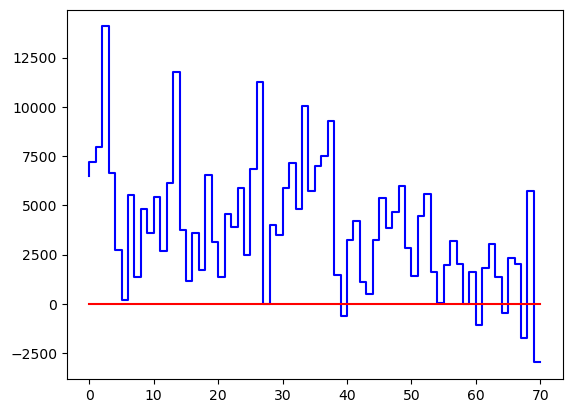

In [39]:
term1_np = term1.float().cpu().numpy()
term2_np = term2.float().cpu().numpy()
x_axis = np.arange(0,term1_np.shape[0])
for i in range(1):
    plt.step(x_axis, term1_np[:,i],label='hh',color='blue')
    plt.step(x_axis, term2_np[:,i],label='ww',color='red')
    #plt.plot(np.abs(term1_np[:,i]),label='hh',color='blue')
    #plt.plot(np.abs(term2_np[:,i]),label='ww',color='red')
#plt.ylim(-1,1)
#plt.yscale('log')

In [40]:
residual_u_valid.norm(dim=1).max()

tensor(1.3750, device='cuda:0', dtype=torch.bfloat16)

# DEBUG

In [8]:
# Sainty check for label/logit alignment

@torch.no_grad()
def debug_one_position(model, tokenizer, sample, pos):
    device = next(model.parameters()).device
    sample = to_device(sample, device)

    input_ids = safe_squeeze_1d(sample["input_ids"]).unsqueeze(0)
    attention_mask = safe_squeeze_1d(sample["attention_mask"]).unsqueeze(0)
    labels = safe_squeeze_1d(sample["labels"]).unsqueeze(0)

    pred_pos = pos - 1
    assert pos >= 1
    assert labels[0, pos].item() != IGNORE_INDEX

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_hidden_states=True,
        use_cache=False,
    )
    logits = outputs.logits[0, pred_pos, :]
    probs = F.softmax(logits, dim=-1)
    pred_id = probs.argmax().item()
    target_id = labels[0, pos].item()

    print(f"label position      : {pos}")
    print(f"predict position    : {pred_pos}")
    print(f"prefix last token   : {repr(tokenizer.decode([input_ids[0, pred_pos].item()]))}")
    print(f"target token        : {repr(tokenizer.decode([target_id]))}")
    print(f"predicted token     : {repr(tokenizer.decode([pred_id]))}")

In [12]:
MODEL = 'Qwen/Qwen3.5-0.8B'
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL,
    padding_side="right",
    truncation_side="right",
    trust_remote_code=True,
    #use_fast=False 
)
dataset = load_dataset("openai/gsm8k",'main',split="train")
processor = GSM8KTokenizerProcessor(model_name_or_path=MODEL,max_length=500)
processed_dataset = processor.process_dataset(dataset)

model = AutoModelForCausalLM.from_pretrained(MODEL,trust_remote_code=True,).to(device)

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

In [17]:
for i in tqdm(range(1)):
    sample = processed_dataset[i]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 6335.81it/s]


In [21]:
debug_one_position(model, tokenizer, sample, pos=91)

label position      : 91
predict position    : 90
prefix last token   : '2'
target token        : '4'
predicted token     : '4'


In [3]:
import torch
from transformers import AutoTokenizer

class AnthropicHHTokenizerProcessor:
    def __init__(self, model_name_or_path: str, max_length: int = 1024):
        self.tokenizer = AutoTokenizer.from_pretrained(
            model_name_or_path,
            padding_side="right",
            truncation_side="right",
            trust_remote_code=True,
        )
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        self.max_length = max_length

    def _split_prompt_and_target(self, text: str):
        marker = "\n\nAssistant:"
        idx = text.rfind(marker)
        if idx == -1:
            raise ValueError("Cannot find the last '\\n\\nAssistant:' marker in chosen text.")

        prompt_text = text[: idx + len(marker)]
        target_text = text[idx + len(marker):]

        # 去掉 target 前面可能多出来的空格，但不强行 strip 全部，避免改动原始 tokenization 太多
        if len(target_text) > 0 and target_text[0] == " ":
            target_text = target_text[1:]

        return prompt_text, target_text

    def process_example(self, example, text_key: str = "chosen"):
        full_text = example[text_key]
        prompt_text, target_text = self._split_prompt_and_target(full_text)

        full_enc = self.tokenizer(
            full_text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        prompt_enc = self.tokenizer(
            prompt_text,
            max_length=self.max_length,
            truncation=True,
            return_tensors="pt",
        )

        input_ids = full_enc["input_ids"][0]
        attention_mask = full_enc["attention_mask"][0]

        prompt_len = prompt_enc["input_ids"].shape[1]

        labels = input_ids.clone()
        labels[:prompt_len] = -100
        labels[attention_mask == 0] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "prompt_text": prompt_text,
            "target_text": target_text,
            "target_start": prompt_len - 1,
        }

    def process_dataset(self, dataset, text_key: str = "chosen"):
        processed = []
        for ex in dataset:
            processed.append(self.process_example(ex, text_key=text_key))
        return processed

In [8]:
from datasets import load_dataset

dataset_hh = load_dataset("Anthropic/hh-rlhf", split="test")
processor = AnthropicHHTokenizerProcessor(model_name_or_path=MODEL, max_length=1024)
processed_hh = processor.process_dataset(dataset_hh, text_key="chosen")